# OU process

In [22]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================
# OU Dataset
# x0 ~ N(10, 2)
# dX_t = - beta X_t dt + sigma dW_t
# ============================================================

mu0 = 10.0
var0 = 2.0
std0 = np.sqrt(var0)

beta = 1.0
sigma = np.sqrt(beta * 2.0)
t = 5.0

N = 10000

# x0 ~ N(mu0, var0)
x0_np = np.random.normal(
    mu0,
    std0,
    N
).astype(np.float32)

# OU conditional mean and variance
a_t = np.exp(-beta * t)

cond_var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
cond_std_t = np.sqrt(cond_var_t)

# xt | x0
eps_np = np.random.randn(N).astype(np.float32)

xt_np = (
    a_t * x0_np
    + cond_std_t * eps_np
).astype(np.float32)

# OU marginal mean and variance
mu_t = a_t * mu0

var_t = (
    (a_t**2) * var0
    + cond_var_t
)

# exact marginal score ∇ log p_t(x)
score_t_np = (
    -(xt_np - mu_t)
    / var_t
).astype(np.float32)

# conditional score ∇ log p(xt | x0)
cond_score_np = (
    -(xt_np - a_t * x0_np)
    / cond_var_t
).astype(np.float32)

# torch tensors
x0_train = torch.tensor(x0_np).view(-1, 1)
xt_train = torch.tensor(xt_np).view(-1, 1)
score_t_train = torch.tensor(score_t_np).view(-1, 1)
cond_score_train = torch.tensor(cond_score_np).view(-1, 1)

print("mu_t =", mu_t)
print("var_t =", var_t)
print("conditional variance =", cond_var_t)
print("xt empirical mean =", xt_np.mean())
print("xt empirical var =", xt_np.var())

mu_t = 0.06737946999085467
var_t = 1.0000453999297627
conditional variance = 0.9999546000702377
xt empirical mean = 0.065197006
xt empirical var = 0.9910509


In [23]:
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [31]:
# ============================================================
# Time-dependent OU training
# with ESM / ISM / DSM / I_DSM
# ============================================================

T = 5.0

epochs = 5000
batch_size = 2048

L_ESM_history = []
L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

for epoch in range(epochs):

    # ========================================================
    # sample x0
    # ========================================================

    x0 = (
        torch.randn(batch_size, 1)
        * np.sqrt(var0)
        + mu0
    )

    # ========================================================
    # sample t ~ Uniform(0,T)
    # ========================================================

    eps_t = 0.05

    t_batch = (
        eps_t
        + (T - eps_t) * torch.rand(batch_size, 1)
    )

    # ========================================================
    # OU coefficients
    # ========================================================

    a_t = torch.exp(-beta * t_batch)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - torch.exp(-2 * beta * t_batch))
    )

    cond_std_t = torch.sqrt(cond_var_t)

    # ========================================================
    # generate xt
    # ========================================================

    eps = torch.randn_like(x0)

    xt = (
        a_t * x0
        + cond_std_t * eps
    )

    xt.requires_grad_(True)

    # ========================================================
    # marginal distribution p_t(x)
    # ========================================================

    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    # ========================================================
    # exact marginal score
    # ∇ log p_t(x_t)
    # ========================================================

    score_t = (
        -(xt - mu_t)
        / var_t
    )

    # ========================================================
    # conditional score
    # ∇ log p(x_t | x0)
    # ========================================================

    cond_score = (
        -(xt - a_t * x0)
        / cond_var_t
    )

    # ========================================================
    # network prediction
    # ========================================================

    pred_score = model(xt, t_batch)

    # ========================================================
    # 1. L_ESM
    # ========================================================

    L_ESM = (
        (pred_score - score_t)**2
    ).mean()

    # ========================================================
    # 2. L_ISM
    # ========================================================

    div_score = torch.autograd.grad(
        outputs=pred_score.sum(),
        inputs=xt,
        create_graph=True
    )[0]

    L_ISM = (
        pred_score**2
        + 2 * div_score
    ).mean()

    # ========================================================
    # 3. L_DSM
    # ========================================================

    term1 = (score_t**2).mean()

    term2 = (cond_score**2).mean()

    L_DSM = (
        L_ESM
        - term1
        + term2
    )

    # ========================================================
    # 4. Indicator I_DSM
    # ========================================================

    I_DSM = (
        pred_score**2
        - pred_score * cond_score
    ).mean()

    # ========================================================
    # train
    # ========================================================

    loss = L_ESM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ========================================================
    # record
    # ========================================================

    L_ESM_history.append(L_ESM.item())
    L_ISM_history.append(L_ISM.item())
    L_DSM_history.append(L_DSM.item())
    I_DSM_history.append(I_DSM.item())

    # ========================================================
    # print
    # ========================================================

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"L_ESM = {L_ESM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch    0 | L_ESM = 0.00003030 | L_ISM = -0.91984481 | L_DSM = 0.35976720 | I_DSM = 0.00848533
Epoch  500 | L_ESM = 0.00005641 | L_ISM = -0.92439008 | L_DSM = 0.30594319 | I_DSM = 0.00105662
Epoch 1000 | L_ESM = 0.00024061 | L_ISM = -0.95234823 | L_DSM = 0.18390650 | I_DSM = 0.03144313
Epoch 1500 | L_ESM = 0.00022670 | L_ISM = -0.97974813 | L_DSM = 0.23553020 | I_DSM = 0.00158288
Epoch 2000 | L_ESM = 0.00006857 | L_ISM = -0.92262506 | L_DSM = 0.24466622 | I_DSM = 0.01695055
Epoch 2500 | L_ESM = 0.00001596 | L_ISM = -0.92338645 | L_DSM = 0.33726901 | I_DSM = -0.01581464
Epoch 3000 | L_ESM = 0.00012309 | L_ISM = -0.98120064 | L_DSM = 0.25975889 | I_DSM = 0.00893213
Epoch 3500 | L_ESM = 0.00001931 | L_ISM = -0.91251034 | L_DSM = 0.30925030 | I_DSM = -0.00199964
Epoch 4000 | L_ESM = 0.00006365 | L_ISM = -0.99435401 | L_DSM = 0.24602962 | I_DSM = 0.01240515
Epoch 4500 | L_ESM = 0.00006112 | L_ISM = -0.89841914 | L_DSM = 0.26378733 | I_DSM = 0.00207846


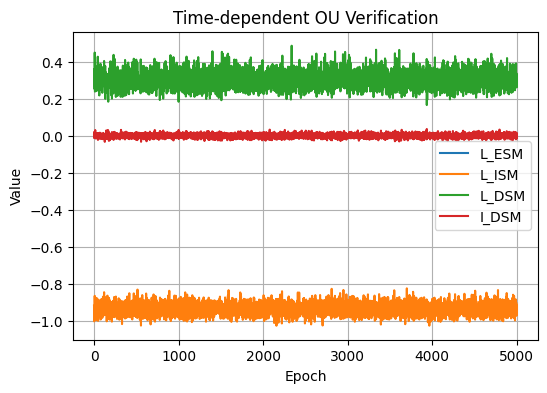

In [36]:
plt.figure(figsize=(6,4))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

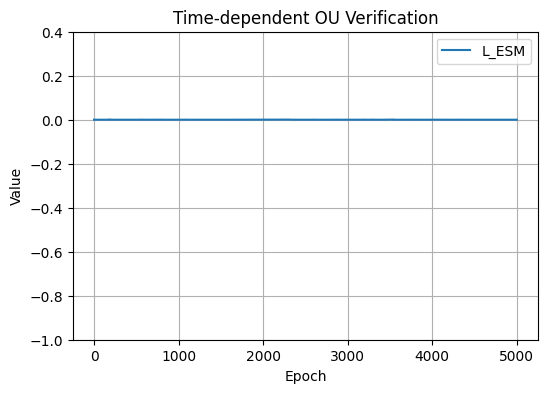

In [40]:
plt.figure(figsize=(6,4))

plt.plot(L_ESM_history, label='L_ESM')
#plt.plot(L_ISM_history, label='L_ISM')
#plt.plot(L_DSM_history, label='L_DSM')
#plt.plot(I_DSM_history, label='I_DSM')

plt.ylim(-1.0, 0.4)
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

In [41]:
# ============================================================
# Reverse OU Sampling: x_T -> x_eps -> x_0
# ============================================================

model.eval()

num_samples = 5000
steps = 1000

eps_t = 0.05
dt = (T - eps_t) / steps

# start from p_T
a_T = np.exp(-beta * T)

cond_var_T = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * T))
)

mu_T = a_T * mu0
var_T = (a_T**2) * var0 + cond_var_T

x = torch.randn(num_samples, 1) * np.sqrt(var_T) + mu_T

# ============================================================
# Reverse SDE from T to eps_t
# ============================================================

with torch.no_grad():

    for i in range(steps):

        t_now = T - i * dt

        t_tensor = torch.ones_like(x) * t_now

        score = model(x, t_tensor)

        noise = torch.randn_like(x)

        x = (
            x
            + (beta * x + sigma**2 * score) * dt
            + sigma * np.sqrt(dt) * noise
        )

# x is approximately x_eps
x_eps = x

# ============================================================
# Posterior sampling: x_0 | x_eps
# ============================================================

a_eps = np.exp(-beta * eps_t)

cond_var_eps = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * eps_t))
)

mu_eps = a_eps * mu0

var_eps = (
    (a_eps**2) * var0
    + cond_var_eps
)

# posterior mean of x0 | x_eps
post_mean = (
    mu0
    + (a_eps * var0 / var_eps)
    * (x_eps - mu_eps)
)

# posterior variance of x0 | x_eps
post_var = (
    var0
    - (a_eps**2 * var0**2) / var_eps
)

# sample x0
x0_reverse = (
    post_mean
    + torch.sqrt(torch.tensor(post_var)) * torch.randn_like(post_mean)
)

samples_reverse = x0_reverse.cpu().numpy().flatten()

print("Reverse mean:", samples_reverse.mean())
print("Reverse std:", samples_reverse.std())

print("Target p0 mean:", mu0)
print("Target p0 std:", np.sqrt(var0))

Reverse mean: 9.966063
Reverse std: 1.4197407
Target p0 mean: 10.0
Target p0 std: 1.4142135623730951


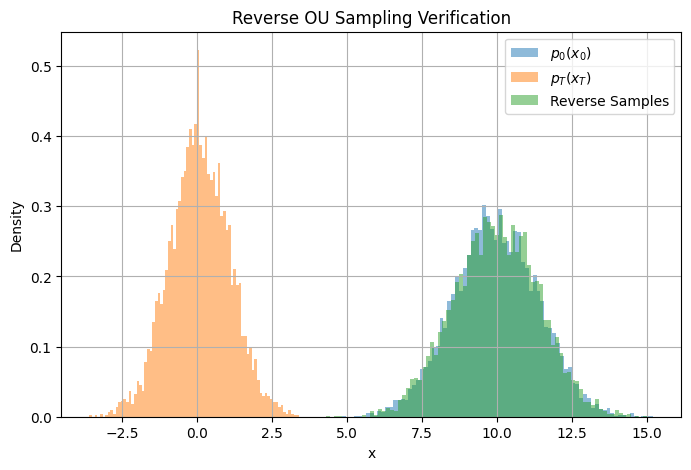

In [43]:
x0_true = np.random.normal(mu0, np.sqrt(var0), 5000)
xT_true = np.random.normal(mu_T, np.sqrt(var_T), 5000)

plt.figure(figsize=(8,5))

plt.hist(x0_true, bins=80, density=True, alpha=0.5, label=r'$p_0(x_0)$')
plt.hist(xT_true, bins=80, density=True, alpha=0.5, label=r'$p_T(x_T)$')
plt.hist(samples_reverse, bins=80, density=True, alpha=0.5, label='Reverse Samples')

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Reverse OU Sampling Verification")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# ============================================================
# Reverse OU trajectory: x_T -> x_eps -> x_0
# ============================================================

num_samples = 5000
steps = 2000

eps_t = 0.05
dt = (T - eps_t) / steps

save_times = [5, 4, 3, 2, 1]

save_indices = {
    int(round((T - t_save) / dt)): t_save
    for t_save in save_times
}

# start from p_T
x = torch.randn(num_samples, 1) * np.sqrt(var_T) + mu_T

saved_samples = {}

model.eval()

with torch.no_grad():

    for i in range(steps + 1):

        if i in save_indices:
            t_save = save_indices[i]
            saved_samples[t_save] = x.cpu().numpy().flatten()

        if i == steps:
            break

        t_now = T - i * dt
        t_tensor = torch.ones_like(x) * t_now

        score = model(x, t_tensor)
        noise = torch.randn_like(x)

        x = (
            x
            + (beta * x + sigma**2 * score) * dt
            + sigma * np.sqrt(dt) * noise
        )

# x is x_eps
x_eps = x

# posterior sampling x0 | x_eps
a_eps = np.exp(-beta * eps_t)

cond_var_eps = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * eps_t))
)

mu_eps = a_eps * mu0

var_eps = (
    (a_eps**2) * var0
    + cond_var_eps
)

post_mean = (
    mu0
    + (a_eps * var0 / var_eps)
    * (x_eps - mu_eps)
)

post_var = (
    var0
    - (a_eps**2 * var0**2) / var_eps
)

x0_reverse = (
    post_mean
    + torch.sqrt(torch.tensor(post_var)) * torch.randn_like(post_mean)
)

saved_samples[0] = x0_reverse.cpu().numpy().flatten()

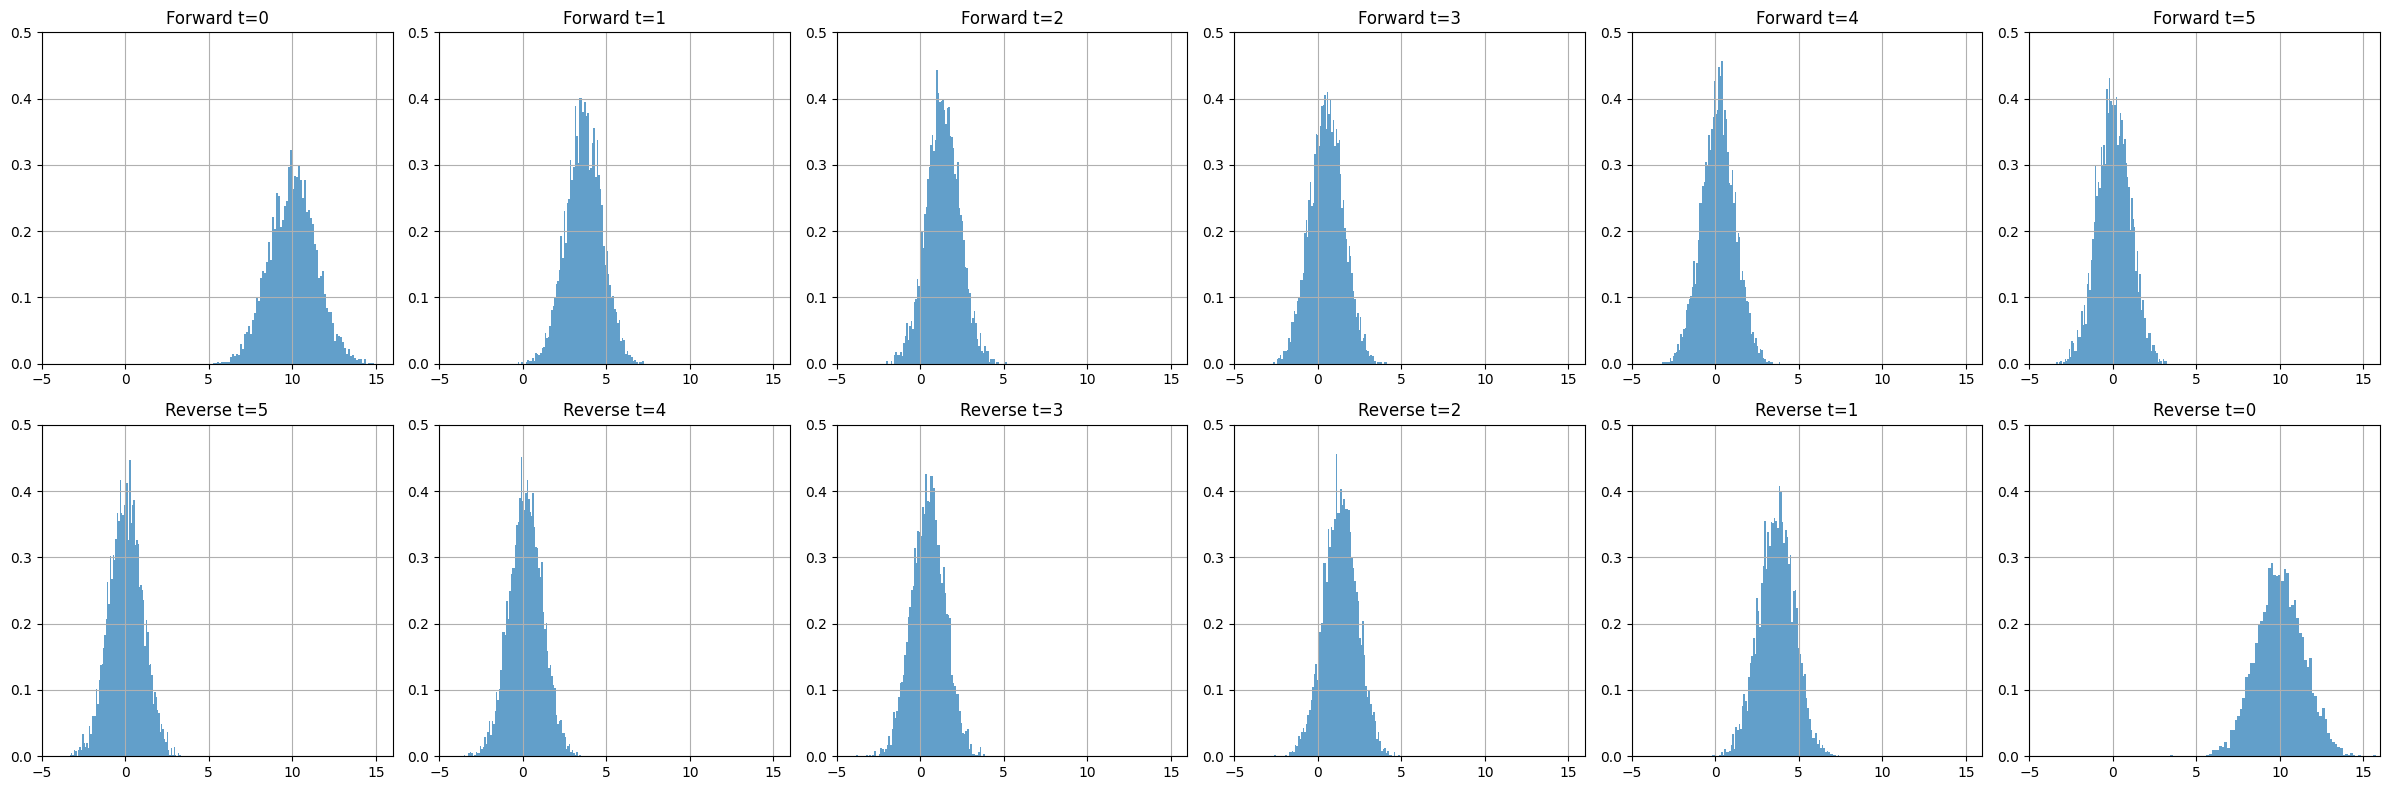

In [49]:
fig, axes = plt.subplots(2, 6, figsize=(24, 8))

times_forward = [0, 1, 2, 3, 4, 5]
times_reverse = [5, 4, 3, 2, 1, 0]

# Forward row
for idx, t_now in enumerate(times_forward):
    a_t = np.exp(-beta * t_now)
    cond_var_t = sigma**2 / (2 * beta) * (1 - np.exp(-2 * beta * t_now))

    mu_t_now = a_t * mu0
    var_t_now = (a_t**2) * var0 + cond_var_t

    xt = np.random.normal(mu_t_now, np.sqrt(var_t_now), 5000)

    ax = axes[0, idx]
    ax.hist(xt, bins=80, density=True, alpha=0.7)
    ax.set_title(f'Forward t={t_now}')
    ax.set_xlim(-5, 16)
    ax.set_ylim(0, 0.5)
    ax.grid(True)

# Reverse row
for idx, t_now in enumerate(times_reverse):
    ax = axes[1, idx]
    ax.hist(saved_samples[t_now], bins=80, density=True, alpha=0.7)
    ax.set_title(f'Reverse t={t_now}')
    ax.set_xlim(-5, 16)
    ax.set_ylim(0, 0.5)
    ax.grid(True)

plt.tight_layout()
plt.show()